<a href="https://colab.research.google.com/github/Ayushibansal805/ML_Lab/blob/main/lab_ml5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"deepti10648yadav","key":"8fb9eb81b8bc796a358fca1a4d231425"}'}

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d lukechugh/best-alzheimer-mri-dataset-99-accuracy

Dataset URL: https://www.kaggle.com/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy
License(s): MIT
100% 71.5M/71.5M [00:00<00:00, 138MB/s]



In [ ]:
!unzip best-alzheimer-mri-dataset-99-accuracy.zip -d alzheimer_dataset

Streaming output truncated to the last 5000 lines.
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (1106).jpg  
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (1107).jpg  
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (1108).jpg  
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (1109).jpg  
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (111).jpg  
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (1110).jpg  
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (1111).jpg  
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (1112).jpg  
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (1113).jpg  
  inflating: alzheimer_dataset/Combined Dataset/train/No Impairment/NoImpairment (1114).jpg  
  inflatin

In [ ]:
import os
for root, dirs, files in os.walk("alzheimer_dataset"):
    print(root, len(files))

alzheimer_dataset 0
alzheimer_dataset/Combined Dataset 0
alzheimer_dataset/Combined Dataset/train 0
alzheimer_dataset/Combined Dataset/train/Very Mild Impairment 2560
alzheimer_dataset/Combined Dataset/train/Moderate Impairment 2560
alzheimer_dataset/Combined Dataset/train/No Impairment 2560
alzheimer_dataset/Combined Dataset/train/Mild Impairment 2560
alzheimer_dataset/Combined Dataset/test 0
alzheimer_dataset/Combined Dataset/test/Very Mild Impairment 448
alzheimer_dataset/Combined Dataset/test/Moderate Impairment 12
alzheimer_dataset/Combined Dataset/test/No Impairment 640
alzheimer_dataset/Combined Dataset/test/Mild Impairment 179


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
#import optimizer and loss function
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_generator = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True)
train_data = train_generator.flow_from_directory('/content/alzheimer_dataset/Combined Dataset/train', target_size=(224, 224), batch_size=32, class_mode='categorical')

Found 10240 images belonging to 4 classes.


In [ ]:
test_generator = ImageDataGenerator(rescale=1./255)
test_data = test_generator.flow_from_directory('/content/alzheimer_dataset/Combined Dataset/test', target_size=(224, 224), batch_size=32, class_mode='categorical')

Found 1279 images belonging to 4 classes.


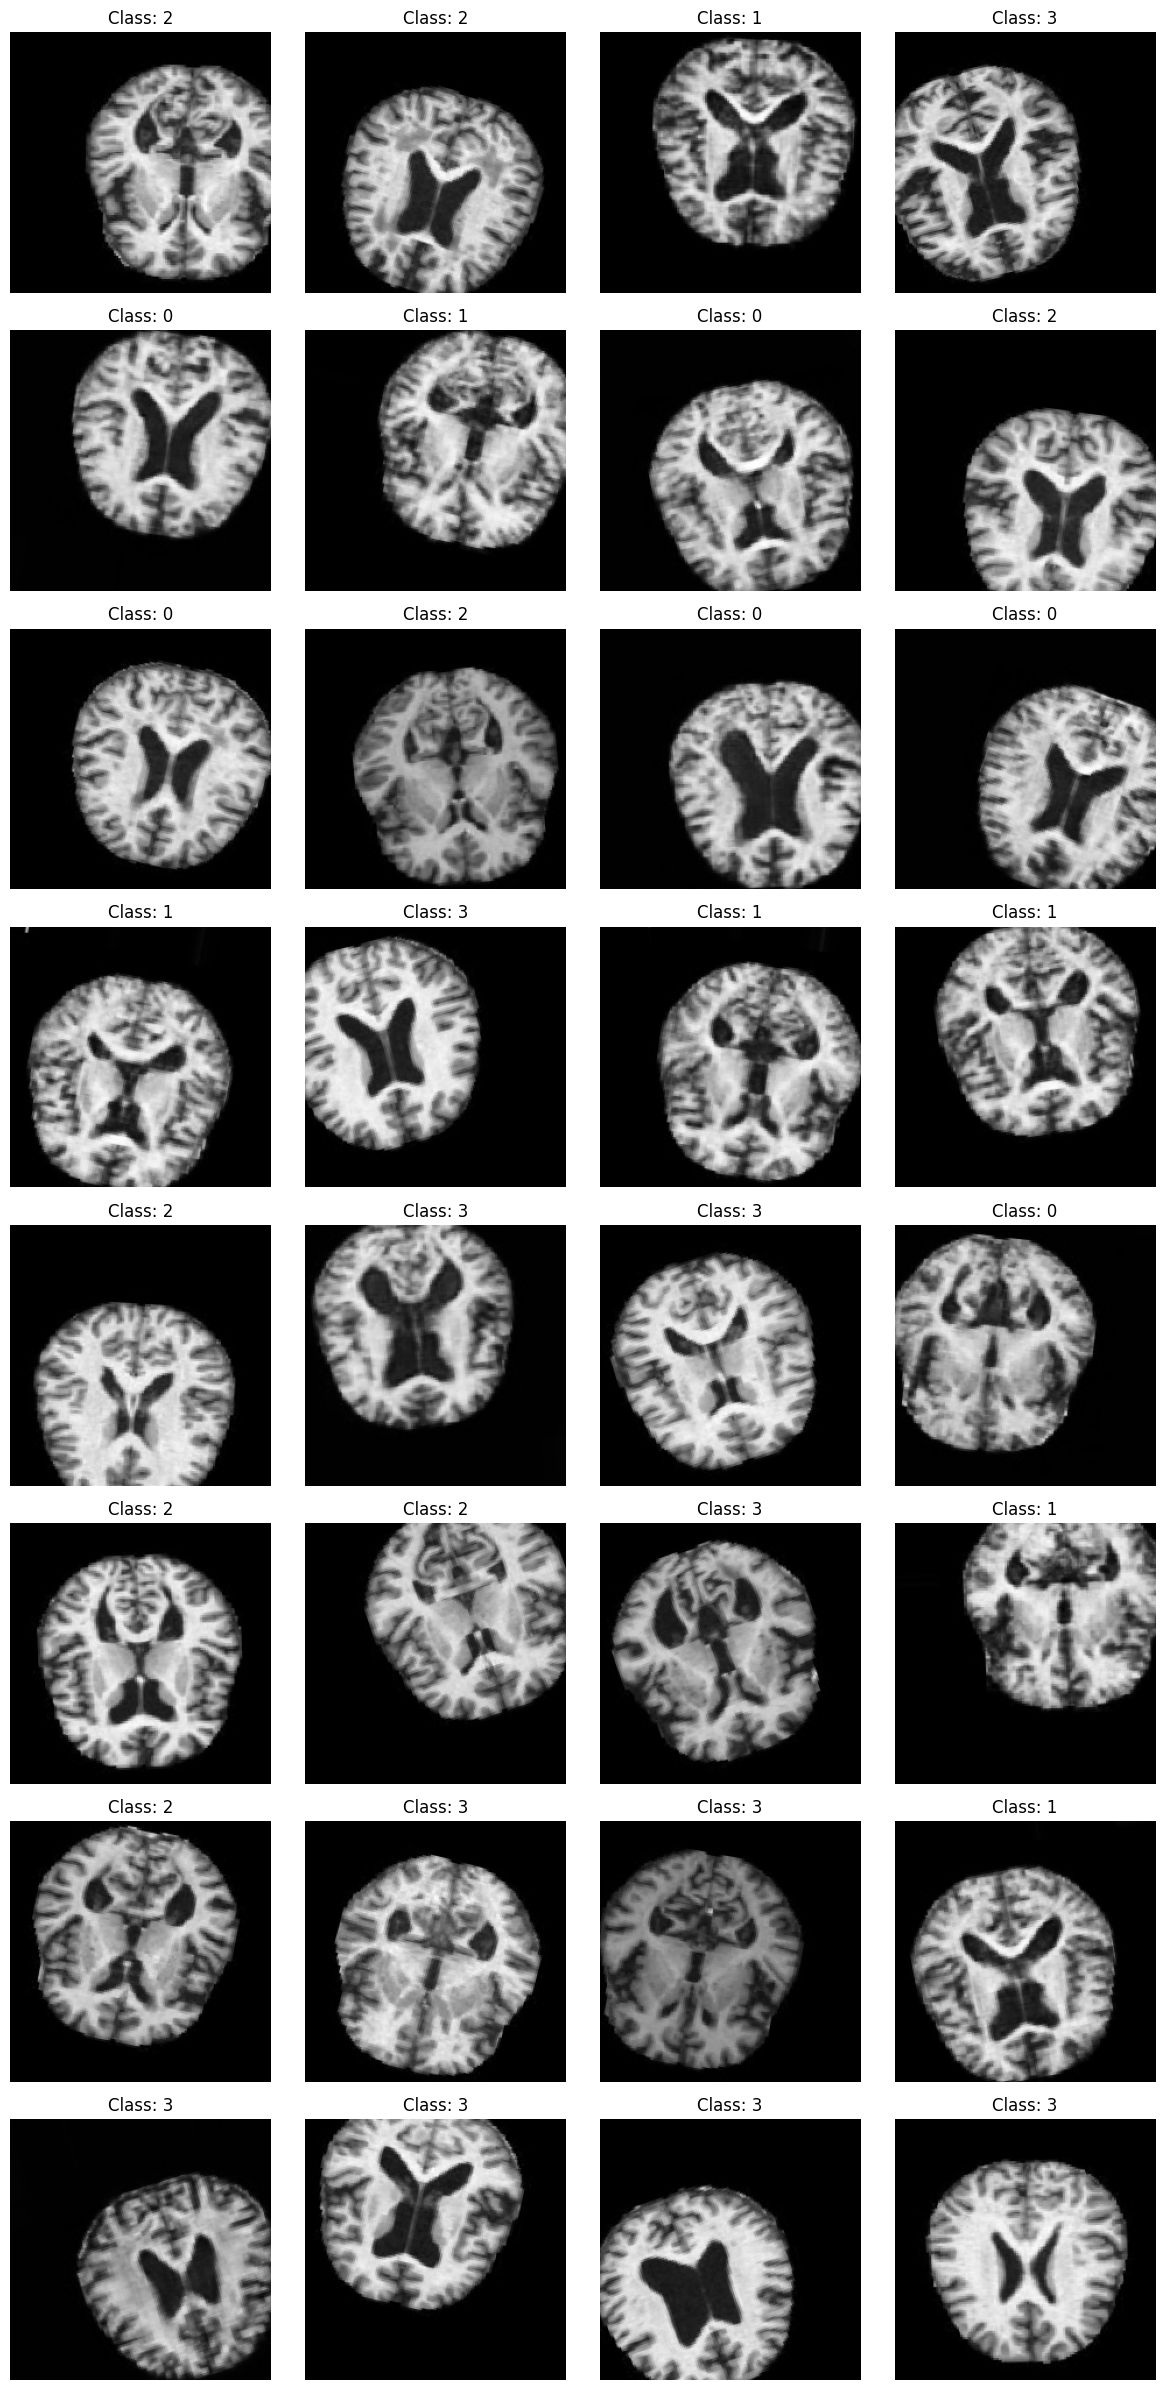

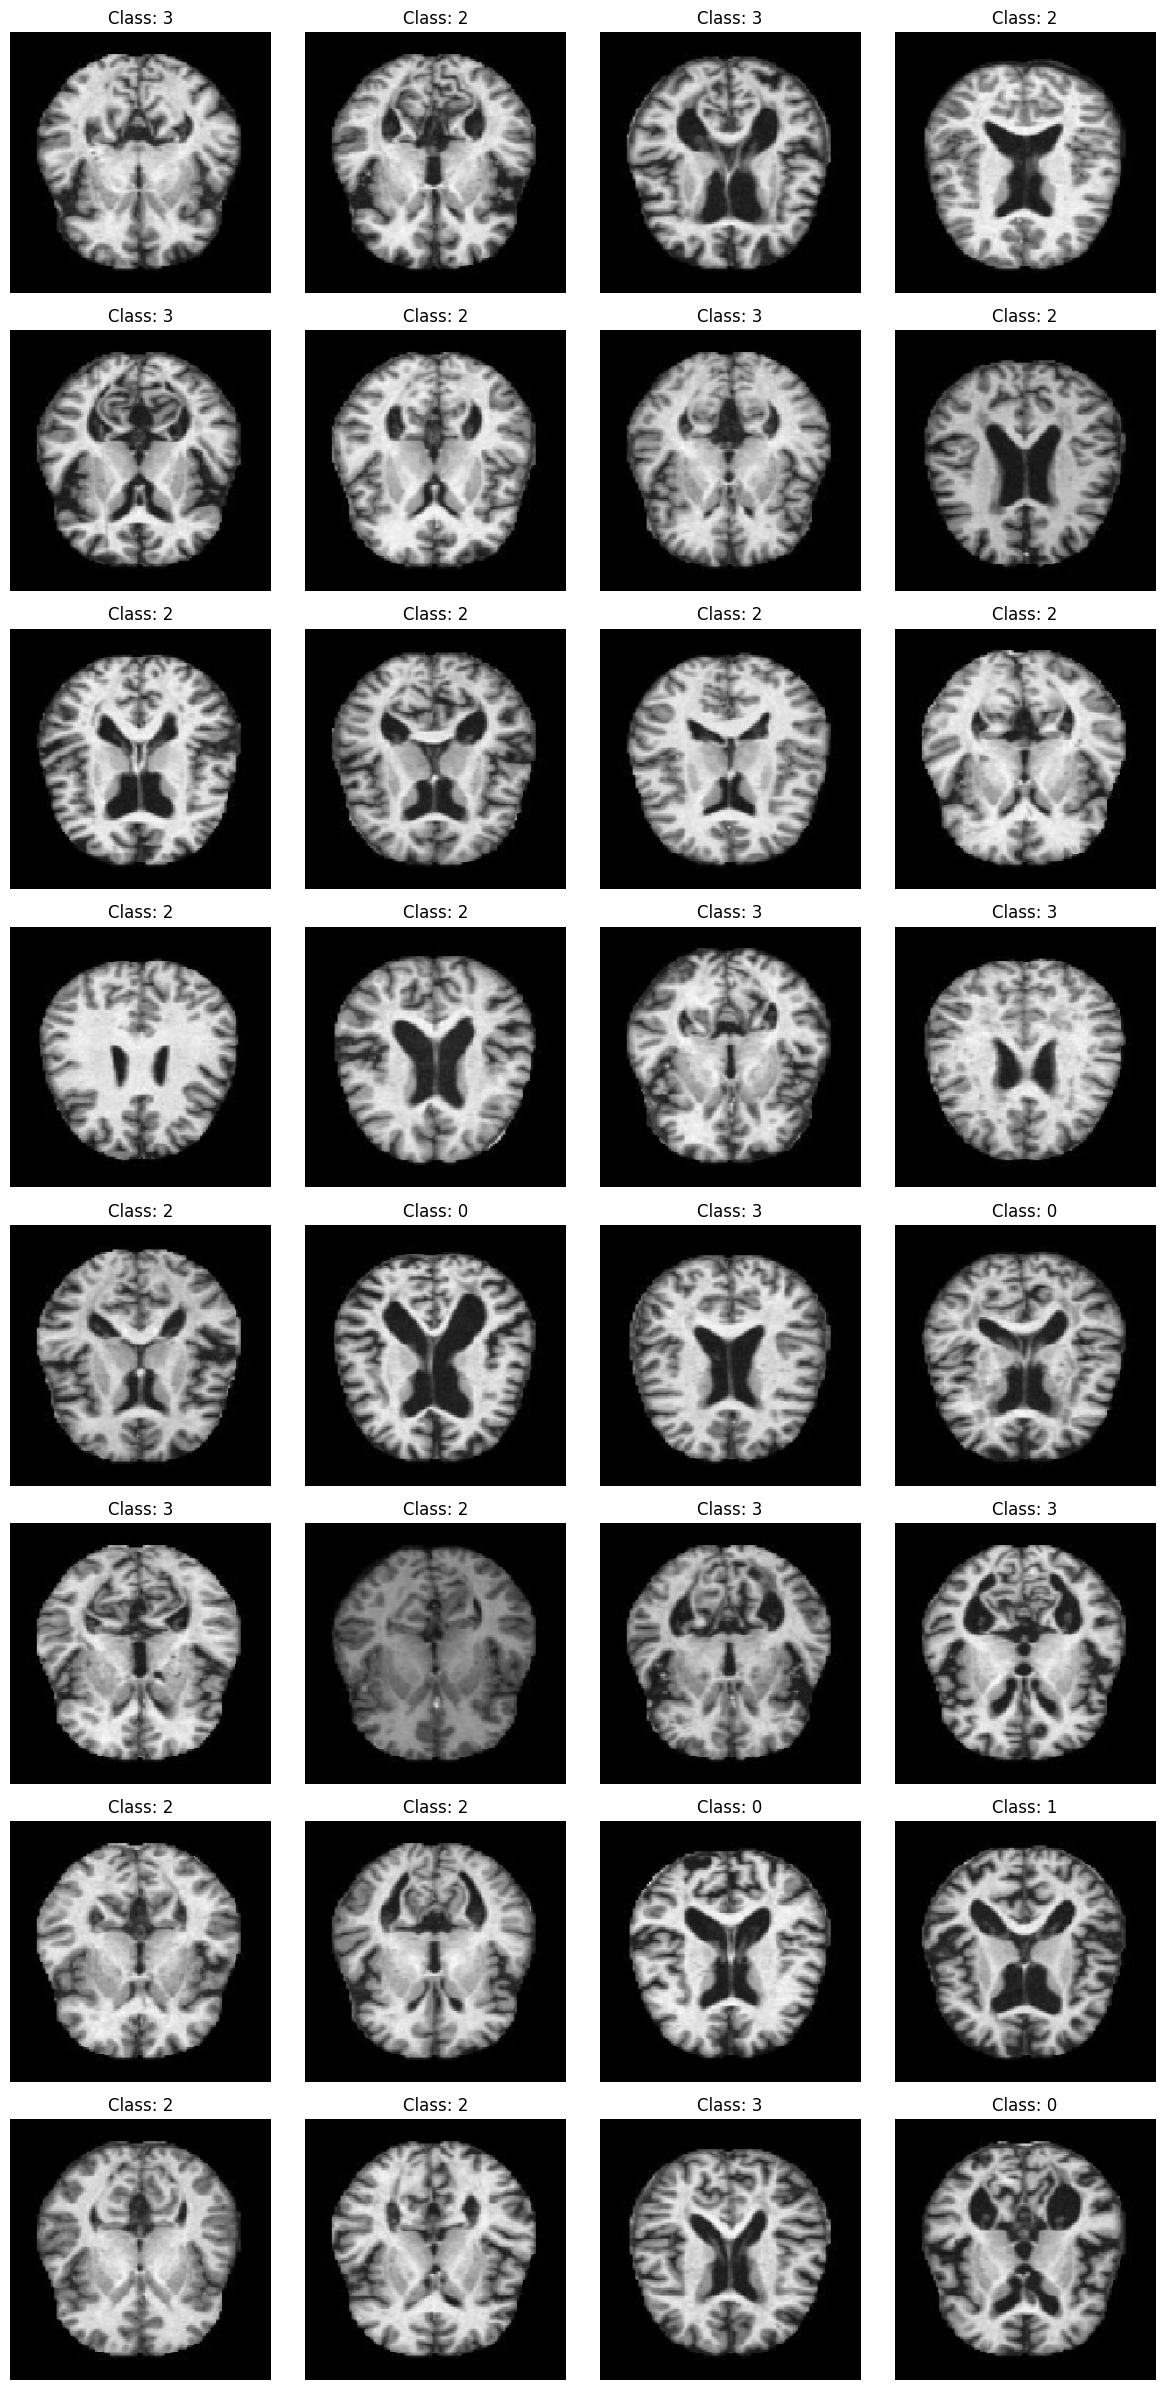

In [ ]:
#@title Plotting an images
import math
# Function to plot images
def plot_images(images, labels):
    num_images = images.shape[0]
    num_rows = int(math.ceil(num_images / 4))
    fig, axes = plt.subplots(num_rows, 4, figsize=(12, 3 * num_rows))
    for i in range(num_images):
        row = i // 4
        col = i % 4
        axes[row, col].imshow(images[i])
        axes[row, col].set_title(f"Class: {np.argmax(labels[i])}")
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()


# Get a batch of training images and labels
train_images, train_labels = next(train_data)

# Get a batch of testing images and labels
test_images, test_labels = next(test_data)

# Plot a few images from the training and testing data
import matplotlib.pyplot as plt
import numpy as np
plot_images(train_images, train_labels)
plot_images(test_images, test_labels)

In [ ]:
model = Sequential([Conv2D(64,(3,3),activation="relu", input_shape=(224, 224, 3), strides=1,padding='same'),
                    Conv2D(64,(3,3), activation='relu', strides=1, padding='same'),
                    MaxPooling2D((2,2)),
                    Conv2D(128, (3, 3), activation='relu',strides=1, padding='same'),
                    Conv2D(128, (3,3), activation='relu', strides=1, padding='same'),
                    MaxPooling2D((2,2)),
                    Conv2D(256, (3, 3), activation='relu', strides=1, padding='same'),
                    Conv2D(256, (3, 3), activation='relu', strides=1, padding='same'),
                    Conv2D(256, (3, 3), activation='relu', strides=1, padding='same'),
                    MaxPooling2D((2, 2)),
                    Conv2D(512, (3, 3), activation='relu', strides=1, padding='same'),
                    Conv2D(512, (3, 3), activation='relu', strides=1, padding='same'),
                    Conv2D(512, (3, 3), activation='relu', strides=1, padding='same'),
                    MaxPooling2D((2, 2)),
                    Flatten(),
                    Dense(4096, activation='relu'),
                    Dense(4, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_compile = model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
print(train_data.class_indices)

{'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}


In [ ]:
# History = model.fit(train_data, epochs=5, validation_data=test_data, verbose=1)

In [ ]:
from tensorflow.keras.applications import VGG16

from tensorflow.keras.models import Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
  layer.trainable = False
num_classes = 4
x = Flatten()(base_model.output)
# x1 = Dense(4096, activation='relu')(x)
# x2 = Dense(1000, activation='relu')(x1)

#output generating layer
predictions = Dense(num_classes, activation='softmax')(x)

#final model
model = Model(inputs=base_model.input, outputs=predictions)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │       100,356 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,815,044 (56.51 MB)

 Trainable params: 100,356 (392.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.callbacks import TensorBoard
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

r2 = model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    verbose=1,
    steps_per_epoch=50,
    validation_steps=10,
    callbacks = [TensorBoard(log_dir='./logs')]
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 489ms/step - accuracy: 0.4306 - loss: 1.4233 - val_accuracy: 0.4875 - val_loss: 1.1054
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 481ms/step - accuracy: 0.6006 - loss: 0.9372 - val_accuracy: 0.5625 - val_loss: 0.9653
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 468ms/step - accuracy: 0.6313 - loss: 0.8834 - val_accuracy: 0.4719 - val_loss: 1.2610
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 479ms/step - accuracy: 0.6556 - loss: 0.8678 - val_accuracy: 0.5312 - val_loss: 0.9391
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 834ms/step - accuracy: 0.6531 - loss: 0.8306 - val_accuracy: 0.5562 - val_loss: 0.9682
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 494ms/step - accuracy: 0.6344 - loss: 0.8632 - val_accuracy: 0.5688 - val_loss: 0.8923
Epoch 7/50
20/50 ━━━━━━━━━━━━━━━━━━━━ 12s 427ms/step - accuracy: 0.6135 - loss: 0.8826

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - accuracy: 0.6406 - loss: 0.8121 - val_accuracy: 0.5188 - val_loss: 1.0604
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 512ms/step - accuracy: 0.7025 - loss: 0.6957 - val_accuracy: 0.5094 - val_loss: 1.2729
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 830ms/step - accuracy: 0.7088 - loss: 0.7307 - val_accuracy: 0.5250 - val_loss: 1.0778
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 490ms/step - accuracy: 0.7100 - loss: 0.6862 - val_accuracy: 0.6094 - val_loss: 0.9170
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 492ms/step - accuracy: 0.7175 - loss: 0.6877 - val_accuracy: 0.6344 - val_loss: 0.8355
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 479ms/step - accuracy: 0.7219 - loss: 0.6667 - val_accuracy: 0.6156 - val_loss: 0.9271
Epoch 13/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 483ms/step - accuracy: 0.7225 - loss: 0.6872 - val_accuracy: 0.6219 - val_loss: 0.8294
Epoch 14/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.7516 - loss: 0.6216 - val_accuracy: 

In [ ]:
loss, acc = model.evaluate(test_data)
print("accuracy", acc)

40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 666ms/step - accuracy: 0.6224 - loss: 1.0626
accuracy 0.6223612427711487


In [ ]:
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
predictions = Dense(4, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

r2=model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    steps_per_epoch=50,
    validation_steps=10
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 579ms/step - accuracy: 0.5719 - loss: 4.0895 - val_accuracy: 0.5000 - val_loss: 2.6255
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 756ms/step - accuracy: 0.6075 - loss: 3.1074 - val_accuracy: 0.4719 - val_loss: 3.2682
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 405ms/step - accuracy: 0.6300 - loss: 2.8033 - val_accuracy: 0.5750 - val_loss: 2.3104
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 402ms/step - accuracy: 0.6544 - loss: 2.4242 - val_accuracy: 0.4750 - val_loss: 2.6566
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 420ms/step - accuracy: 0.6187 - loss: 3.1284 - val_accuracy: 0.5344 - val_loss: 2.6950
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.6388 - loss: 2.6723 - val_accuracy: 0.5312 - val_loss: 2.2543
Epoch 7/50
20/50 ━━━━━━━━━━━━━━━━━━━━ 10s 351ms/step - accuracy: 0.6328 - loss: 2.7295

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.6203 - loss: 2.9966 - val_accuracy: 0.4844 - val_loss: 3.3898
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 431ms/step - accuracy: 0.6656 - loss: 2.6001 - val_accuracy: 0.4656 - val_loss: 4.2723
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 418ms/step - accuracy: 0.6288 - loss: 2.9848 - val_accuracy: 0.5750 - val_loss: 1.8213
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 426ms/step - accuracy: 0.6513 - loss: 3.0111 - val_accuracy: 0.5063 - val_loss: 3.1682
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 422ms/step - accuracy: 0.6488 - loss: 3.0580 - val_accuracy: 0.4812 - val_loss: 3.2473
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 400ms/step - accuracy: 0.6731 - loss: 2.8929 - val_accuracy: 0.4656 - val_loss: 4.1316
Epoch 13/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 427ms/step - accuracy: 0.6744 - loss: 2.5055 - val_accuracy: 0.3375 - val_loss: 8.6164
Epoch 14/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.6578 - loss: 3.5375 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(test_data)
print("accuracy", acc)

40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - accuracy: 0.5496 - loss: 4.0934
accuracy 0.5496481657028198


In [ ]:
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
predictions = Dense(4, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    steps_per_epoch=50,
    validation_steps=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 490ms/step - accuracy: 0.4600 - loss: 8.5350 - val_accuracy: 0.4187 - val_loss: 4.7668
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 365ms/step - accuracy: 0.6031 - loss: 3.1733 - val_accuracy: 0.3906 - val_loss: 7.1541
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 398ms/step - accuracy: 0.6456 - loss: 2.7979 - val_accuracy: 0.4469 - val_loss: 3.7665
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 370ms/step - accuracy: 0.6675 - loss: 2.4368 - val_accuracy: 0.5031 - val_loss: 5.2870
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 415ms/step - accuracy: 0.6575 - loss: 2.4425 - val_accuracy: 0.4938 - val_loss: 5.3282
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 364ms/step - accuracy: 0.6894 - loss: 2.5238 - val_accuracy: 0.5031 - val_loss: 12.1434
Epoch 7/50
20/50 ━━━━━━━━━━━━━━━━━━━━ 11s 394ms/step - accuracy: 0.6652 - loss: 3.1006

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.6766 - loss: 2.9837 - val_accuracy: 0.4938 - val_loss: 7.1364
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 395ms/step - accuracy: 0.6719 - loss: 3.2404 - val_accuracy: 0.5125 - val_loss: 4.6829
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 368ms/step - accuracy: 0.6806 - loss: 2.8124 - val_accuracy: 0.5750 - val_loss: 6.2736
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 392ms/step - accuracy: 0.6938 - loss: 2.6730 - val_accuracy: 0.4344 - val_loss: 5.3051
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 373ms/step - accuracy: 0.6806 - loss: 2.9115 - val_accuracy: 0.5188 - val_loss: 5.3369
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 398ms/step - accuracy: 0.6787 - loss: 3.2899 - val_accuracy: 0.4750 - val_loss: 7.3355
Epoch 13/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 373ms/step - accuracy: 0.7019 - loss: 2.8198 - val_accuracy: 0.5312 - val_loss: 5.9194
Epoch 14/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.7047 - loss: 2.7976 - val_accuracy: 

In [ ]:
loss, acc = model.evaluate(test_data)
print("accuracy", acc)

40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 335ms/step - accuracy: 0.5238 - loss: 4.8046
accuracy 0.5238467454910278


In [ ]:
from tensorflow.keras.applications import ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
predictions = Dense(4, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    steps_per_epoch=50,
    validation_steps=10
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 512ms/step - accuracy: 0.2912 - loss: 4.2268 - val_accuracy: 0.3125 - val_loss: 1.5482
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 408ms/step - accuracy: 0.3562 - loss: 1.4830 - val_accuracy: 0.1750 - val_loss: 1.7688
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 427ms/step - accuracy: 0.3650 - loss: 1.6752 - val_accuracy: 0.2219 - val_loss: 2.0440
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 408ms/step - accuracy: 0.4075 - loss: 1.4155 - val_accuracy: 0.4563 - val_loss: 1.6044
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 417ms/step - accuracy: 0.4025 - loss: 1.4456 - val_accuracy: 0.4313 - val_loss: 2.1304
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 425ms/step - accuracy: 0.4025 - loss: 1.6409 - val_accuracy: 0.4906 - val_loss: 1.3334
Epoch 7/50
20/50 ━━━━━━━━━━━━━━━━━━━━ 10s 344ms/step - accuracy: 0.4237 - loss: 1.5068

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.4172 - loss: 1.5047 - val_accuracy: 0.3688 - val_loss: 1.4345
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 437ms/step - accuracy: 0.4238 - loss: 1.6491 - val_accuracy: 0.3500 - val_loss: 1.5002
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 433ms/step - accuracy: 0.4356 - loss: 1.4331 - val_accuracy: 0.4469 - val_loss: 1.2690
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 409ms/step - accuracy: 0.4700 - loss: 1.2623 - val_accuracy: 0.5094 - val_loss: 1.5732
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 833ms/step - accuracy: 0.4106 - loss: 1.6885 - val_accuracy: 0.5281 - val_loss: 0.9583
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 418ms/step - accuracy: 0.4487 - loss: 1.5260 - val_accuracy: 0.3344 - val_loss: 2.5364
Epoch 13/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 402ms/step - accuracy: 0.4700 - loss: 1.5486 - val_accuracy: 0.4563 - val_loss: 1.4544
Epoch 14/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.4359 - loss: 1.4388 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(test_data)
print("accuracy", acc)

40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - accuracy: 0.3667 - loss: 1.7371
accuracy 0.3666927218437195


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    steps_per_epoch=50,
    validation_steps=10
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 553ms/step - accuracy: 0.2463 - loss: 4.3422 - val_accuracy: 0.0094 - val_loss: 5.2592
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 752ms/step - accuracy: 0.2438 - loss: 2.0448 - val_accuracy: 0.1219 - val_loss: 3.7594
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - accuracy: 0.2612 - loss: 2.5856 - val_accuracy: 0.0031 - val_loss: 5.3357
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 369ms/step - accuracy: 0.2500 - loss: 2.7711 - val_accuracy: 0.0063 - val_loss: 3.6833
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 395ms/step - accuracy: 0.2406 - loss: 2.3243 - val_accuracy: 0.0094 - val_loss: 2.7763
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 416ms/step - accuracy: 0.2531 - loss: 1.8726 - val_accuracy: 0.3406 - val_loss: 1.1288
Epoch 7/50
20/50 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - accuracy: 0.2713 - loss: 1.6267

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.2531 - loss: 1.8006 - val_accuracy: 0.3250 - val_loss: 1.3836
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 369ms/step - accuracy: 0.2525 - loss: 2.0350 - val_accuracy: 0.1469 - val_loss: 1.4967
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 414ms/step - accuracy: 0.2537 - loss: 2.0043 - val_accuracy: 0.3625 - val_loss: 1.4836
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 367ms/step - accuracy: 0.2544 - loss: 2.7707 - val_accuracy: 0.3313 - val_loss: 2.4985
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 399ms/step - accuracy: 0.2387 - loss: 2.2132 - val_accuracy: 0.1375 - val_loss: 2.3530
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step - accuracy: 0.2612 - loss: 2.2265 - val_accuracy: 0.3438 - val_loss: 4.8779
Epoch 13/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 354ms/step - accuracy: 0.2544 - loss: 2.6105 - val_accuracy: 0.0063 - val_loss: 3.6162
Epoch 14/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.2562 - loss: 2.4169 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(test_data)
print("accuracy", acc)

40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 255ms/step - accuracy: 0.5004 - loss: 2.1627
accuracy 0.5003909468650818
